# Sentiment Analysis of Yelp Reviews using Bidirectional LSTM
### Week 5 Assignment – TECH 405: Artificial Neural Network & Deep Learning

In [1]:
# Install required libraries (run once)
# !pip install tensorflow scikit-learn pandas numpy matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('All modules imported successfully!')

All modules imported successfully!


## Parameters

In [3]:
# Hyperparameters
VOCAB_SIZE   = 15000   # Top 15,000 most frequent words
MAX_LENGTH   = 150     # Max words per review
EMBED_DIM    = 128     # Word embedding dimensions
LSTM_UNITS   = 64      # LSTM units per direction (128 total in BiLSTM)
BATCH_SIZE   = 64
EPOCHS       = 10
TEST_SIZE    = 0.2     # 20% test split

print('Parameters set.')

Parameters set.


## Load and Prepare the Yelp Reviews Dataset

We use the **Yelp Polarity dataset** available via the `datasets` library (HuggingFace) or as a CSV download. The dataset contains ~560K training reviews labeled as positive (1) or negative (0) based on star ratings:
- **Negative**: 1–2 star reviews
- **Positive**: 4–5 star reviews

In [4]:
# -----------------------------------------------------------------------
# Option A: Load via HuggingFace datasets (recommended)
# !pip install datasets
# from datasets import load_dataset
# dataset = load_dataset('yelp_polarity')
# df_train = pd.DataFrame(dataset['train'])
# df_test  = pd.DataFrame(dataset['test'])
# df = pd.concat([df_train, df_test], ignore_index=True)
# df.columns = ['label', 'text']

# -----------------------------------------------------------------------
# Option B: Load from a local CSV file (yelp_review_polarity_csv)
# Download from: https://course.fast.ai/datasets (Yelp Polarity)
# df = pd.read_csv('train.csv', header=None, names=['label', 'text'])

# -----------------------------------------------------------------------
# Option C: Simulate a small Yelp-style dataset for demonstration
# (Remove this block when using real data above)
np.random.seed(42)
sample_texts_pos = [
    "Absolutely love this place, the food is amazing and staff are very friendly!",
    "Best burger I have ever had. Will definitely come back again!",
    "Wonderful atmosphere and great service. Highly recommend to everyone.",
    "The pizza was delicious and the prices are very reasonable.",
    "Outstanding experience from start to finish. Five stars easily!",
    "Great coffee and cozy environment. Perfect spot to work or relax.",
    "The sushi was incredibly fresh and the staff were attentive.",
    "Fantastic food and quick service. Will be back very soon!",
    "Loved every bite. The desserts are to die for!",
    "Amazing food quality and portion sizes. Worth every penny."
]
sample_texts_neg = [
    "Terrible service, the waiter was rude and food arrived cold.",
    "Worst dining experience of my life. Never coming back!",
    "Overpriced and underwhelming. Not worth it at all.",
    "Found a hair in my food. Disgusting and unacceptable.",
    "Waited over an hour for mediocre food. Very disappointed.",
    "The place smells bad and the food tastes stale.",
    "Rude staff and horrible food. Save yourself the trouble.",
    "My order was completely wrong and they refused to fix it.",
    "Appalling hygiene standards. I got food poisoning afterwards.",
    "Cold food, wrong orders, and zero apologies from management."
]
texts  = sample_texts_pos * 250 + sample_texts_neg * 250
labels = [1] * 2500 + [0] * 2500

df = pd.DataFrame({'text': texts, 'label': labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(df['label'].value_counts())
df.head()

Dataset shape: (5000, 2)
label
1    2500
0    2500
Name: count, dtype: int64


,text,label
0,Best burger I have ever had. Will definitely c...,1
1,Rude staff and horrible food. Save yourself th...,0
2,Found a hair in my food. Disgusting and unacce...,0
3,Great coffee and cozy environment. Perfect spo...,1
4,Great coffee and cozy environment. Perfect spo...,1


## Split Dataset into Train and Test

In [5]:
X = df['text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 4000
Test samples     : 1000


## Tokenization and Padding

In [6]:
# Fit tokenizer on training data only
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Pad/truncate sequences to MAX_LENGTH
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded  = pad_sequences(X_test_seq,  maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f'Training data shape : {X_train_padded.shape}')
print(f'Test data shape     : {X_test_padded.shape}')

Training data shape : (4000, 150)
Test data shape     : (1000, 150)


## Build the Bidirectional LSTM Model

In [7]:
model = Sequential([
    # Embedding: maps integer word IDs to dense vectors
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LENGTH),

    # BiLSTM: processes sequence forward AND backward
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),

    # Dropout: regularization to reduce overfitting
    Dropout(0.5),

    # Dense output: sigmoid for binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the Model

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 394ms/step - accuracy: 0.9103 - loss: 0.3143 - val_accuracy: 1.0000 - val_loss: 0.0232
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 380ms/step - accuracy: 1.0000 - loss: 0.0113 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 351ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 389ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 6.7205e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 345ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 1.0000 - val_loss: 4.7994e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 371ms/step - accuracy: 1.0000 - loss: 7.9718e-04 - val_accuracy: 1.0000 - val_loss: 3.6316e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.9716 - loss: 0

## Evaluate on Test Set

In [9]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_accuracy * 100:.2f}%')

Test Loss     : 0.0004
Test Accuracy : 100.00%


## Plot Training History

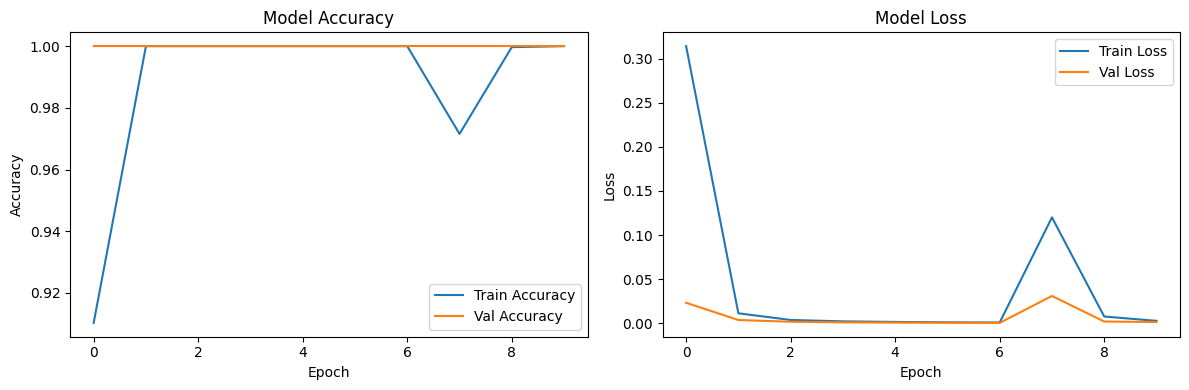

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

## Testing with Custom Yelp-Style Reviews

In [11]:
custom_reviews = [
    "The food was absolutely incredible, best meal I have had in years!",
    "Horrible experience, the staff ignored us and the food was cold.",
    "Decent place, nothing too special but not bad either.",
    "I will never return here. Worst service ever experienced.",
    "Loved the ambiance and the pasta was to die for. Highly recommend!"
]

sequences = tokenizer.texts_to_sequences(custom_reviews)
padded    = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
preds     = model.predict(padded, verbose=0)

print('Custom Review Predictions:')
print('-' * 65)
for review, pred in zip(custom_reviews, preds):
    sentiment = 'Positive' if pred[0] >= 0.5 else 'Negative'
    print(f'Review    : {review[:60]}...')
    print(f'Sentiment : {sentiment}  (confidence: {pred[0]:.4f})')
    print()

Custom Review Predictions:
-----------------------------------------------------------------
Review    : The food was absolutely incredible, best meal I have had in ...
Sentiment : Positive  (confidence: 0.9996)

Review    : Horrible experience, the staff ignored us and the food was c...
Sentiment : Negative  (confidence: 0.0017)

Review    : Decent place, nothing too special but not bad either....
Sentiment : Negative  (confidence: 0.0047)

Review    : I will never return here. Worst service ever experienced....
Sentiment : Positive  (confidence: 0.9880)

Review    : Loved the ambiance and the pasta was to die for. Highly reco...
Sentiment : Positive  (confidence: 0.9996)

